In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
from langdetect import detect
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
import csv
file_name = 'lists/result.csv'
file_name_2 = 'lists/clear_data.csv'
file_name_3 = 'lists/data_without_emoji.csv'

In [ ]:
def remove_emoji(string):
    emoji_pattern = re.compile("["
                               u"\U0001F600-\U0001F64F"  # emoticons
                               u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                               u"\U0001F680-\U0001F6FF"  # transport & map symbols
                               u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                               u"\U00002500-\U00002BEF"  # chinese char
                               u"\U00002702-\U000027B0"
                               u"\U00002702-\U000027B0"
                               u"\U000024C2-\U0001F251"
                               u"\U0001f926-\U0001f937"
                               u"\U00010000-\U0010ffff"
                               u"\u2640-\u2642"
                               u"\u2600-\u2B55"
                               u"\u200d"
                               u"\u23cf"
                               u"\u23e9"
                               u"\u231a"
                               u"\ufe0f"  # dingbats
                               u"\u3030"
                               "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', string)

def clear_dataframe():
    df = pd.read_csv(file_name)
    comments = df['comment'].values
    clear_comments = []
    for comment in comments:
        clear_comments.append(remove_emoji(comment))
    df['comment'] = df['comment'].replace(df['comment'].values, clear_comments)
    index_list = []
    for index, comment in enumerate(df['comment'].values):
        if len(comment) < 20 or len(comment) > 500:
            index_list.append(index)
    df.drop(index=index_list, axis=0, inplace=True)
    df.to_csv(file_name_2, encoding='utf-8', index=False)
def data_without_emoji():
    df = pd.read_csv(file_name)
    df = df.dropna()
    comments = df['comment'].values
    clear_comments = []
    for comment in comments:
        clear_comments.append(remove_emoji(comment))
    df['comment'] = df['comment'].replace(df['comment'].values, clear_comments)
    df = df.dropna()
    df.to_csv(file_name_3, encoding='utf-8', index=False)


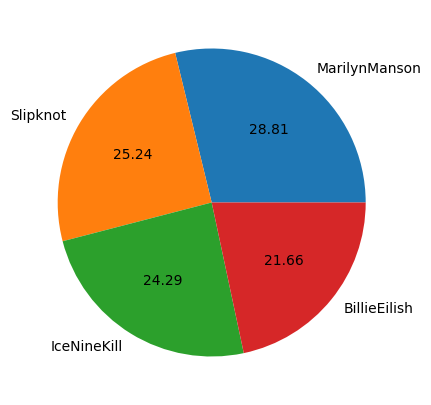

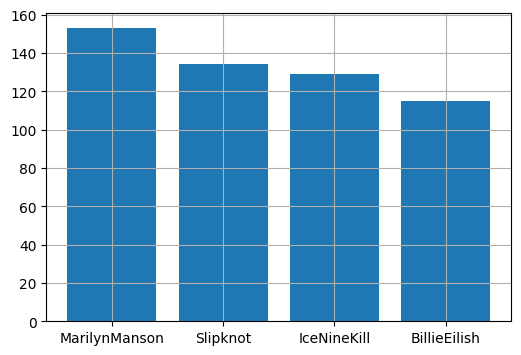

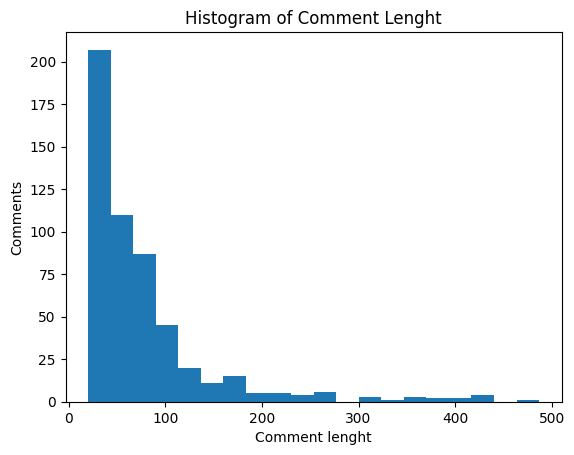

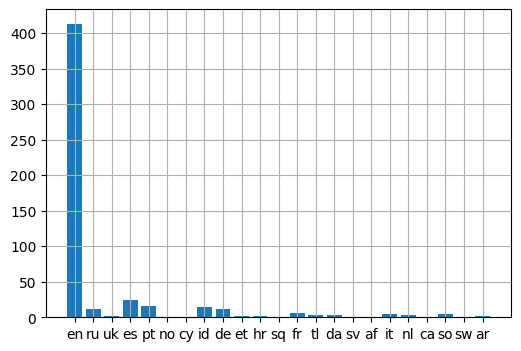

[nltk_data] Downloading package punkt to /home/tembane/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


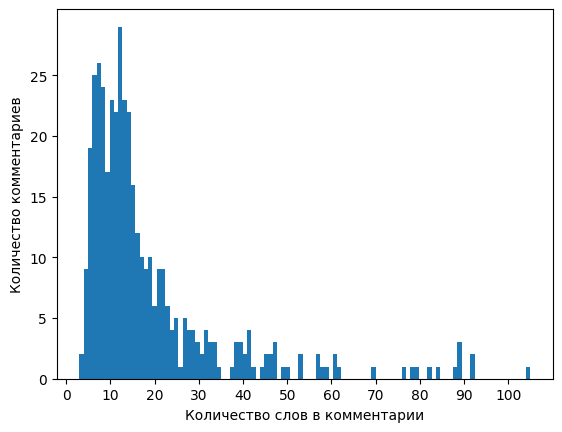

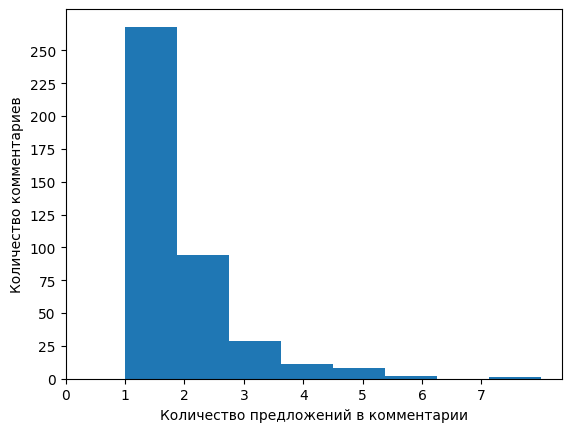

In [2]:
def save_dict_to_csv(filename, dictionary):
    with open(filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['Key', 'Value'])
        for key, value in dictionary.items():
            for v in value:
                writer.writerow([key, v])

def language_detect():
    df = pd.read_csv(file_name_2)
    comments = df['comment'].values
    languages = set()
    for comment in comments:
        languages.add(detect(comment))
    res_dict = dict()
    for comment in comments:
        comment_lang = detect(comment)
        if (comment_lang in languages) and (comment_lang not in res_dict.keys()):
            res_dict[comment_lang] = []
        if comment_lang in languages:
            res_dict[comment_lang].append(comment)

    save_dict_to_csv('data.csv', res_dict)
    return res_dict

def pie_chart():
    df = pd.read_csv(file_name_2)
    performer = df['performer'].unique()
    performer_comments_value = df['performer'].value_counts().values
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot()
    ax.pie(performer_comments_value, labels=performer, autopct='%.02f')
    ax.grid()
    plt.show()


def bar_chart():
    df = pd.read_csv(file_name_2)
    performer = df['performer'].unique()
    performer_comments_value = df['performer'].value_counts().values
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot()
    name = [f'{name}' for name in performer]
    comm_count = np.array(performer_comments_value)
    ax.bar(name, comm_count)
    ax.grid()
    plt.show()


def bar_chart_len_comment():
    df = pd.read_csv(file_name_2)
    comments = df['comment'].values
    len_comments = [len(i) for i in comments]
    plt.hist(len_comments, bins=20)
    plt.title('Histogram of Comment Lenght')
    plt.xlabel('Comment lenght')
    plt.ylabel('Comments')
    plt.show()


def visualization_lang():
    comm_dict = language_detect()
    langs = comm_dict.keys()
    comments_len = list()
    for key in comm_dict.keys():
        comments_len.append(len(comm_dict[key]))
    fig = plt.figure(figsize=(6, 4))
    ax = fig.add_subplot()
    ax.bar(langs, comments_len)
    ax.grid()
    plt.show()


def visualization_word():
    df = pd.read_csv('data.csv')
    eng_comments = df.loc[df.Key == 'en', 'Value'].tolist()
    nltk.download('punkt')
    word_counts = [len(word_tokenize(comment)) for comment in eng_comments]
    comm_len_df = pd.DataFrame({'Word count': word_counts})
    plt.hist(comm_len_df['Word count'], bins=max(comm_len_df['Word count']))
    plt.xticks(range(0, max(comm_len_df['Word count']), 10))
    plt.yticks(range(0, 30, 5))
    plt.xlabel('Количество слов в комментарии')
    plt.ylabel('Количество комментариев')
    plt.show()
def visualization_sent():
    df = pd.read_csv('data.csv')
    eng_comments = df.loc[df.Key == 'en', 'Value'].tolist()
    sent_count = [len(sent_tokenize(comment)) for comment in eng_comments]
    sents_df = pd.DataFrame({'Sent_count': sent_count})
    plt.hist(sents_df['Sent_count'], bins=max(sents_df['Sent_count']))
    plt.xticks(range(0, max(sents_df['Sent_count'])))
    plt.yticks(range(0, 251, 25))
    plt.xlabel('Количество предложений в комментарии')
    plt.ylabel('Количество комментариев')
    plt.show()


def visualization():
    pie_chart()
    bar_chart()
    bar_chart_len_comment()
    visualization_lang()
    visualization_word()
    visualization_sent()


def main():
    visualization()


if __name__ == '__main__':
    main()